# LSTM temporel (TensorFlow/Keras) — prévision Heat Index & Wind Chill (era5land)

Approche **séries temporelles par station** en **TensorFlow/Keras** (inspirée de
`lstm_heat_index_prediction.ipynb`). On entraîne et compare trois modèles
temporels — **LSTM**, **GRU**, **StackedLSTM** — sur data era5 land depuis GEE : à partir
des `INPUT_WINDOW` derniers jours de variables météo, on prédit les
`OUTPUT_WINDOW` prochains jours de **HeatIndex** et **WindChill**.


## 0. Imports & configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip -q install pyarrow

import os, glob, json, math, gc, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pyarrow.parquet as pqx
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings; warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [ ]:
# ── Configuration centrale du benchmark (source de vérité unique) ──
from dataclasses import dataclass, field, asdict
from typing import List
import os
from pathlib import Path
import numpy as np
import tensorflow as tf
import json

@dataclass
class Config:
    """Tous les hyperparamètres, chemins, features et cibles du benchmark LSTM
    temporel (ERA5-Land, tout le Maroc). Modifier ICI propage a tout le notebook."""
    # — Données / chemins —
    data_dir: str = "/content/drive/MyDrive/ERA5_land_LSTM_parquet"  # dossier des parquet ERA5 (déjà convertis)
    art_dir:  str = "/content/drive/MyDrive/lstm_era5_land_morocco/"  # sorties (modèles, scalers, métriques)
    # — Features & cibles (sélectionnées PAR NOM, pas par slicing) —
    features: List[str] = field(default_factory=lambda: [
        "latitude", "longitude", "elevation",
        "tmax_c", "tmin_c", "dewp_c", "humidity_pct",
        "wind_speed_ms", "press_hpa", "heat_index", "wind_chill"
        ])
    targets:  List[str] = field(default_factory=lambda: ["heat_index", "wind_chill"])
    # — Fenêtrage temporel —
    input_window:  int = 7        # jours passés fournis au modèle
    output_window: int = 7        # jours prédits
    # — Split chronologique par station (70 / 15 / 15) —
    train_ratio: float = 0.70
    val_ratio:   float = 0.15
    test_ratio:  float = 0.15
    # — Modèle —
    hidden:   int = 64          # <-- Doubled capacity to fully utilize the GPU
    n_layers: int = 2
    dropout:  float = 0.4       # <-- Lowered dropout so the 2nd layer gets enough signal
    # — Entraînement —
    batch_size: int = 2048      # <-- Massively increased batch size to saturate the GPU!
    epochs:     int = 100
    lr:         float = 1e-4
    patience:   int = 16
    seed:       int = 42

    @property
    def n_features(self) -> int: return len(self.features)
    @property
    def n_targets(self) -> int:  return len(self.targets)

cfg = Config()
assert abs(cfg.train_ratio + cfg.val_ratio + cfg.test_ratio - 1.0) < 1e-9, "les ratios doivent sommer à 1"

# Reproductibilité pilotée par la config
np.random.seed(cfg.seed); tf.random.set_seed(cfg.seed)

# ── Alias module-level (utilisés dans tout le notebook) ──
DATA_DIR = cfg.data_dir
ART_DIR  = Path(cfg.art_dir); ART_DIR.mkdir(parents=True, exist_ok=True)
FEATURES = list(cfg.features)
TARGETS  = list(cfg.targets)
INPUT_WINDOW, OUTPUT_WINDOW = cfg.input_window, cfg.output_window
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = cfg.train_ratio, cfg.val_ratio, cfg.test_ratio
HIDDEN, N_LAYERS, DROPOUT = cfg.hidden, cfg.n_layers, cfg.dropout
BATCH_SIZE, EPOCHS, LR, PATIENCE = cfg.batch_size, cfg.epochs, cfg.lr, cfg.patience

# ── Contrôles RAM (Colab gratuit ≈ 12.7 Go) ──────────────────────────────────
#   On lit les parquet déjà convertis et on échantillonne un sous-ensemble de
#   pixels (stations) réparti uniformément — mêmes pixels sur toutes les années.
MAX_PIXELS = 300     # nb max de pixels/stations ; None = tous (⚠️ RAM)
YEARS      = None    # ex: list(range(2010,2026)) filtre par nom de fichier ; None = tous
MAX_FILES  = None    # ex: 3 pour un test rapide ; None = tous
print(f"RAM ctrl -> max_pixels={MAX_PIXELS}, years={YEARS}, max_files={MAX_FILES}")

print("Config centrale:\n" + json.dumps(asdict(cfg), indent=2, ensure_ascii=False))
print("DATA_DIR:", DATA_DIR)
print("ART_DIR:", ART_DIR)


RAM ctrl -> max_pixels=300, years=None, max_files=None
Config centrale:
{
  "data_dir": "/content/drive/MyDrive/ERA5_land_LSTM_parquet",
  "art_dir": "/content/drive/MyDrive/lstm_era5_land_morocco/",
  "features": [
    "latitude",
    "longitude",
    "elevation",
    "tmax_c",
    "tmin_c",
    "dewp_c",
    "humidity_pct",
    "wind_speed_ms",
    "press_hpa",
    "heat_index",
    "wind_chill"
  ],
  "targets": [
    "heat_index",
    "wind_chill"
  ],
  "input_window": 7,
  "output_window": 7,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "hidden": 64,
  "n_layers": 2,
  "dropout": 0.4,
  "batch_size": 2048,
  "epochs": 100,
  "lr": 0.0001,
  "patience": 16,
  "seed": 42
}
DATA_DIR: /content/drive/MyDrive/ERA5_land_LSTM_parquet
ART_DIR: /content/drive/MyDrive/lstm_era5_land_morocco


## 1. Load all stations

Les données proviennent des **parquet ERA5-Land déjà convertis** (`DATA_DIR = ERA5_land_LSTM_parquet`). Chaque **pixel de grille** est une *station*. Pour tenir dans la RAM de Colab on **échantillonne** `MAX_PIXELS` pixels (répartis uniformément, identiques sur toutes les années) et on lit les parquet en **élaguant colonnes + pixels**.

In [ ]:
# ── Chargement direct des parquet ERA5 (déjà convertis) ──
pq_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.parquet"), recursive=True))
assert pq_files, f"Aucun .parquet dans {DATA_DIR}"
if YEARS:
    yrs = {str(y) for y in YEARS}
    pq_files = [f for f in pq_files if any(y in os.path.basename(f) for y in yrs)]
if MAX_FILES:
    pq_files = pq_files[:MAX_FILES]
print(f"{len(pq_files)} fichier(s) parquet\n")

# Sous-ensemble de pixels (mêmes pixels sur toutes les années -> séries continues)
pix0 = np.sort(pd.read_parquet(pq_files[0], columns=["pixel_id"])["pixel_id"].unique())
if MAX_PIXELS and len(pix0) > MAX_PIXELS:
    step = max(1, len(pix0) // MAX_PIXELS)
    sel = set(pix0[::step][:MAX_PIXELS].tolist())
else:
    sel = set(pix0.tolist())
print(f"pixels retenus : {len(sel)} / {len(pix0)}")

want = ["pixel_id", "date"] + list(dict.fromkeys(FEATURES + TARGETS))
frames = []
for k, f in enumerate(pq_files, 1):
    avail = pqx.ParquetFile(f).schema.names           # lecture colonnes présentes
    cols  = [c for c in want if c in avail]
    df = pd.read_parquet(f, columns=cols)             # column pruning -> RAM
    df = df[df["pixel_id"].isin(sel)]                 # pixel pruning -> RAM
    for c in df.select_dtypes("float64").columns:
        df[c] = df[c].astype("float32")
    frames.append(df)
    print(f"[{k}/{len(pq_files)}] {os.path.basename(f)}: {len(df)} lignes")

data = pd.concat(frames, ignore_index=True); del frames; gc.collect()
# pixel_id -> "station" (compatibilité avec tout le reste du notebook)
data["station"] = data["pixel_id"].astype(str)
data = data.drop(columns=["pixel_id"])
missing = [c for c in FEATURES + TARGETS if c not in data.columns]
assert not missing, f"colonnes manquantes dans les parquet: {missing}"
print("\nstations (pixels):", data["station"].nunique(), "| rows:", len(data))
print("date range:", data["date"].min().date(), "->", data["date"].max().date())
print("RAM du DataFrame:", round(data.memory_usage(deep=True).sum()/1e6, 1), "Mo")
data.head()

36 fichier(s) parquet

pixels retenus : 300 / 6350
[1/36] ERA5_Morocco_1990.parquet: 109200 lignes
[2/36] ERA5_Morocco_1991.parquet: 109200 lignes
[3/36] ERA5_Morocco_1992.parquet: 109500 lignes
[4/36] ERA5_Morocco_1993.parquet: 109200 lignes
[5/36] ERA5_Morocco_1994.parquet: 109200 lignes
[6/36] ERA5_Morocco_1995.parquet: 109200 lignes
[7/36] ERA5_Morocco_1996.parquet: 109500 lignes
[8/36] ERA5_Morocco_1997.parquet: 109200 lignes
[9/36] ERA5_Morocco_1998.parquet: 109200 lignes
[10/36] ERA5_Morocco_1999.parquet: 109200 lignes
[11/36] ERA5_Morocco_2000.parquet: 109500 lignes
[12/36] ERA5_Morocco_2001.parquet: 109200 lignes
[13/36] ERA5_Morocco_2002.parquet: 109200 lignes
[14/36] ERA5_Morocco_2003.parquet: 109200 lignes
[15/36] ERA5_Morocco_2004.parquet: 109500 lignes
[16/36] ERA5_Morocco_2005.parquet: 109200 lignes
[17/36] ERA5_Morocco_2006.parquet: 109200 lignes
[18/36] ERA5_Morocco_2007.parquet: 109200 lignes
[19/36] ERA5_Morocco_2008.parquet: 109500 lignes
[20/36] ERA5_Morocco_2009.p

,date,latitude,longitude,elevation,tmax_c,tmin_c,dewp_c,humidity_pct,wind_speed_ms,press_hpa,heat_index,wind_chill,station
0,1990-01-01,35.850201,-5.45,63.0,15.834503,12.901031,11.943939,77.687614,5.030040,1009.897949,15.502018,14.367767,280
1,1990-01-02,35.850201,-5.45,63.0,17.014191,13.493591,12.365387,74.095490,2.548151,1008.995605,16.705879,15.253891,280
2,1990-01-03,35.850201,-5.45,63.0,14.025757,9.716949,9.238525,72.891106,6.436271,1002.544067,13.387155,11.871353,280
3,1990-01-04,35.850201,-5.45,63.0,13.423767,9.931335,6.938812,64.836845,6.253282,1010.378601,12.514661,11.677551,280
4,1990-01-05,35.850201,-5.45,63.0,14.810883,10.909058,8.603149,66.377411,0.426517,1014.863770,14.080715,12.859970,280


## 2. Clean & feature engineering
- Drop the trailing constant-repeat rows NASA POWER pads at the end of each station.
- Add cyclical day-of-year features for seasonality.

In [ ]:
data = data.sort_values(["station","date"]).reset_index(drop=True)

# Remove consecutive exact-duplicate tail rows (NASA POWER pads the latest days)
def _strip_tail_dupes(g):
    key = ["tmax_c","tmin_c","humidity_pct","press_hpa"]
    dup = (g[key].diff().abs().sum(axis=1) == 0)
    tail_mask = dup & (dup[::-1].cummin()[::-1])
    return g[~tail_mask]
data = pd.concat([_strip_tail_dupes(g) for _, g in data.groupby("station")], ignore_index=True)

# Drop rows with NaN in any used column
need = FEATURES
before = len(data); data = data.dropna(subset=need).reset_index(drop=True)
print(f"dropped {before-len(data)} NaN/dupe rows -> {len(data)} rows")

# ── Redéfinir WindChill en "température ressentie" (Apparent Temperature, Steadman) ──
_e = (data["humidity_pct"] / 100.0) * 6.105 * np.exp(17.27 * data["tmin_c"] / (237.7 + data["tmin_c"]))
data["wind_chill"] = data["tmin_c"] + 0.33 * _e - 0.70 * data["wind_speed_ms"] - 4.00
print(f"wind_chill redéfini (Apparent Temp) | corr avec Tmin: "
      f"{data['wind_chill'].corr(data['tmin_c']):.3f}")

# Cyclical seasonality
# doy = data["date"].dt.dayofyear
# data["doy_sin"] = np.sin(2*np.pi*doy/365.25)
# data["doy_cos"] = np.cos(2*np.pi*doy/365.25)
# FEATURES = FEATURES + ["doy_sin","doy_cos"]
# print("n_features:", len(FEATURES), "| targets:", TARGETS)

dropped 0 NaN/dupe rows -> 3933900 rows
wind_chill redéfini (Apparent Temp) | corr avec Tmin: 0.967


## 2bis. Matrice de corrélation (features & cibles)
Heatmap de Pearson (seaborn) sur le jeu complet **après** nettoyage et ajout des
features de saisonnalité — pour repérer la redondance et les liens avec les
cibles `HeatIndex` / `WindChill` avant l'entraînement.

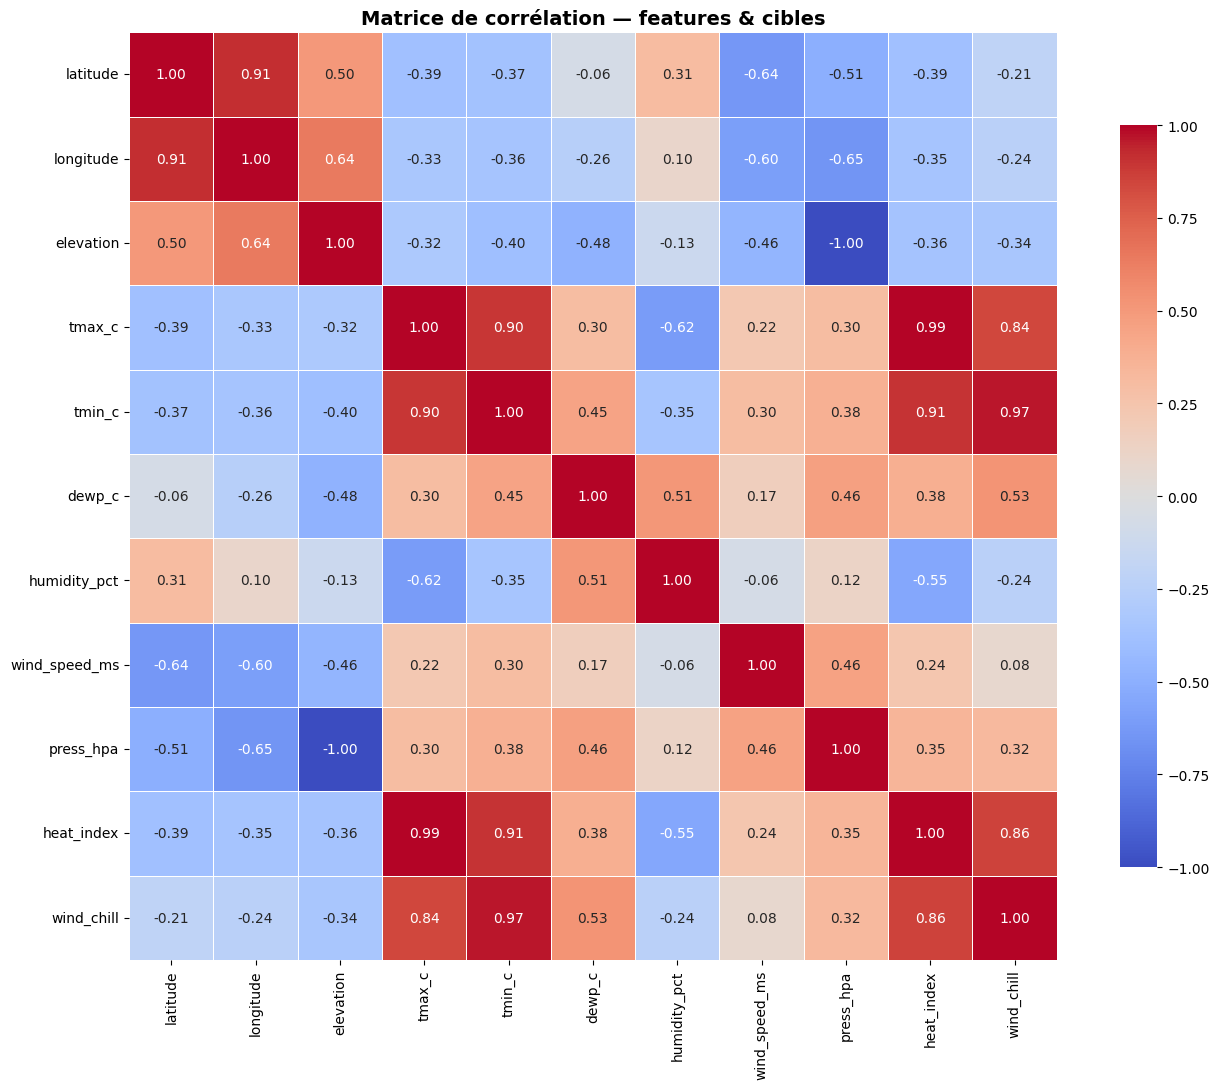

Paires |r| > 0.9 (redondance potentielle):
       press_hpa ~ elevation      r=-0.997
      heat_index ~ tmax_c         r=+0.993
      wind_chill ~ tmin_c         r=+0.967
       longitude ~ latitude       r=+0.914
      heat_index ~ tmin_c         r=+0.906

Top |r| avec heat_index:
tmax_c          0.993
tmin_c          0.906
humidity_pct   -0.553
latitude       -0.388
dewp_c          0.383

Top |r| avec wind_chill:
tmin_c       0.967
tmax_c       0.841
dewp_c       0.525
elevation   -0.342
press_hpa    0.323


In [ ]:
# ── Heatmap de corrélation complète (features + cibles) ──
corr_cols = FEATURES
corr = data[corr_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matrice de corrélation — features & cibles", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# Paires fortement colinéaires (|r| > 0.9, hors diagonale) -> redondance / fuite potentielle
keep = np.tril(np.ones_like(corr, dtype=bool), k=-1)
pairs = corr.where(keep).abs().stack().sort_values(ascending=False)
pairs = pairs[pairs > 0.9]
print("Paires |r| > 0.9 (redondance potentielle):")
for (a, b), _ in pairs.items():
    print(f"  {a:>14s} ~ {b:<14s} r={corr.loc[a, b]:+.3f}")

# Top corrélations (|r|) de chaque cible avec les features
for t in TARGETS:
    order = corr[t].drop(TARGETS).abs().sort_values(ascending=False).head(5).index
    print(f"\nTop |r| avec {t}:")
    print(corr.loc[order, t].round(3).to_string())

## 3. Split chronologique — 70 / 15 / 15
On découpe dans l'ordre temporel : 70 % d'abord (train),
puis 15 % (val), puis 15 % (test).

In [ ]:
def split_station(g):
    g = g.sort_values("date")
    n = len(g)
    i_tr = int(n * TRAIN_RATIO)
    i_va = int(n * (TRAIN_RATIO + VAL_RATIO))
    return g.iloc[:i_tr], g.iloc[i_tr:i_va], g.iloc[i_va:]

parts = [split_station(g) for _, g in data.groupby("station")]
train_df = pd.concat([p[0] for p in parts], ignore_index=True)
val_df   = pd.concat([p[1] for p in parts], ignore_index=True)
test_df  = pd.concat([p[2] for p in parts], ignore_index=True)

tot = len(data)
for name, d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(f"{name:5s}: {len(d):7d} rows ({len(d)/tot*100:4.1f}%)  "
          f"{d['date'].min().date()} -> {d['date'].max().date()}")

train: 2753700 rows (70.0%)  1990-01-01 -> 2015-03-14
val  :  590100 rows (15.0%)  2015-03-15 -> 2020-08-06
test :  590100 rows (15.0%)  2020-08-07 -> 2025-12-30


## 4. Normalisation Z-score

In [ ]:
scaler_X = StandardScaler().fit(train_df[FEATURES])
# On n'a plus besoin de scaler_y car TARGETS est inclus dans FEATURES

def scale(df):
    df = df.copy()
    # Transforme TOUTES les features, ce qui inclut HeatIndex et WindChill
    df[FEATURES] = scaler_X.transform(df[FEATURES])
    return df

train_n, val_n, test_n = scale(train_df), scale(val_df), scale(test_df)
print("features mean (train, post-scale):", np.mean(train_n[FEATURES].to_numpy()[:1000]))

# Affichage des moyennes/écarts-types pour les cibles via scaler_X
tgt_indices = [FEATURES.index(t) for t in TARGETS]
print("targets mean_ :", dict(zip(TARGETS, np.round(scaler_X.mean_[tgt_indices], 2))))
print("targets scale_ (std) :", dict(zip(TARGETS, np.round(scaler_X.scale_[tgt_indices], 2))))

features mean (train, post-scale): -0.24231474227222435
targets mean_ : {'heat_index': np.float64(24.91), 'wind_chill': np.float64(8.55)}
targets scale_ (std) : {'heat_index': np.float64(8.18), 'wind_chill': np.float64(6.67)}


## 5. Windowing — per-station sliding sequences
Windows never cross a station boundary. X = INPUT_WINDOW days of features; y = next OUTPUT_WINDOW days of targets.

In [ ]:
def make_sequences(df_norm):
    Xs, Ys = [], []
    win = INPUT_WINDOW + OUTPUT_WINDOW
    for _, g in df_norm.groupby("station"):
        g = g.sort_values("date")
        F = g[FEATURES].to_numpy(np.float32)
        T = g[TARGETS].to_numpy(np.float32)
        for i in range(len(g) - win + 1):
            Xs.append(F[i:i+INPUT_WINDOW])
            Ys.append(T[i+INPUT_WINDOW:i+win])
    if not Xs:
        return (np.empty((0,INPUT_WINDOW,len(FEATURES)),np.float32),
                np.empty((0,OUTPUT_WINDOW,len(TARGETS)),np.float32))
    return np.stack(Xs), np.stack(Ys)

# ⚠️ WARNING: Running this on the full dataset (all 6350 stations) will CRASH the RAM!
# We comment this out and use the StationWindowGenerator (next cell) instead.
# X_tr, y_tr = make_sequences(train_n)
# X_va, y_va = make_sequences(val_n)
# X_te, y_te = make_sequences(test_n)
# print("X_train:", X_tr.shape, "y_train:", y_tr.shape)


### 5bis. RAM-Efficient Windowing (On-the-fly Generator)
When using `MAX_PIXELS = None`, the `make_sequences` function will crash Colab because the sliding windows duplicate data in memory (requiring >20 GB).

Instead, use this `StationWindowGenerator`. It keeps only the raw data in memory and builds the window batches on-the-fly during training, fitting easily within the 12 GB Colab limit.

In [ ]:
import math
import gc

class StationWindowGenerator(keras.utils.Sequence):
    def __init__(self, df, batch_size=BATCH_SIZE):
        self.batch_size = batch_size
        self.input_window = INPUT_WINDOW
        self.output_window = OUTPUT_WINDOW

        # Convert to numpy once for fast slicing (avoids heavy Pandas overhead)
        self.features = df[FEATURES].values.astype(np.float32)
        self.targets = df[TARGETS].values.astype(np.float32)

        print("Precomputing valid window indices...")
        self.valid_indices = []
        win_size = self.input_window + self.output_window

        # Group by station to find valid index ranges (df is already sorted by date)
        for _, g in df.groupby("station"):
            start_idx = g.index[0]
            end_idx = g.index[-1] - win_size + 1
            if end_idx >= start_idx:
                self.valid_indices.extend(range(start_idx, end_idx + 1))

        self.valid_indices = np.array(self.valid_indices)
        print(f"Total valid windows: {len(self.valid_indices):,}")

    def __len__(self):
        return math.ceil(len(self.valid_indices) / self.batch_size)

    def __getitem__(self, idx):
        # Get the row indices for this specific batch
        batch_start_idx = self.valid_indices[idx * self.batch_size : (idx + 1) * self.batch_size]

        # Pre-allocate batch arrays
        X = np.empty((len(batch_start_idx), self.input_window, len(FEATURES)), dtype=np.float32)
        y = np.empty((len(batch_start_idx), self.output_window, len(TARGETS)), dtype=np.float32)

        # Fill the batch using fast numpy slicing
        for i, start_i in enumerate(batch_start_idx):
            X[i] = self.features[start_i : start_i + self.input_window]
            y[i] = self.targets[start_i + self.input_window : start_i + self.input_window + self.output_window]

        return X, y

# Instantiate the generators (This takes virtually 0 extra RAM!)
train_gen = StationWindowGenerator(train_n)
val_gen = StationWindowGenerator(val_n)
test_gen = StationWindowGenerator(test_n)

# Free up the old huge arrays if they exist to reclaim memory
if 'X_tr' in globals():
    del X_tr, y_tr, X_va, y_va, X_te, y_te
    gc.collect()

Precomputing valid window indices...
Total valid windows: 2,749,800
Precomputing valid window indices...
Total valid windows: 586,200
Precomputing valid window indices...
Total valid windows: 586,200


⚠️ **IMPORTANT**: Now that you are using generators, you must update your `train_keras` function in cell **# 7. Benchmark** to use them:

Change this:
```python
    h = m.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=epochs,
              batch_size=BATCH_SIZE, callbacks=cbs, verbose=1)
```
To this:
```python
    # batch_size is now handled natively by the Generator
    h = m.fit(train_gen, validation_data=val_gen, epochs=epochs,
              callbacks=cbs, verbose=1)
```

And for evaluations, replace `m.predict(X_te)` with `m.predict(test_gen)`.

## 6. Modèles temporels Keras — LSTM · GRU · TCN · BiLSTM · TFT
Cinq architectures partageant la même interface `(INPUT_WINDOW, n_features) -> (OUTPUT_WINDOW, n_targets)`, donc directement comparables. RNN empilés (`N_LAYERS`) ; **BiLSTM** encode la fenêtre dans les deux sens ; **TCN** = convolutions 1D causales dilatées (non-récurrent) ; **TFT** = Temporal Fusion Transformer compact (GRN + encodeur LSTM + self-attention multi-tête).

In [ ]:
def _grn(x, units, dropout=DROPOUT):
    """Gated Residual Network (Lim et al., 2021) — brique de base du TFT.
    Projection ELU -> gating GLU -> connexion résiduelle -> LayerNorm."""
    residual = x if x.shape[-1] == units else layers.Dense(units)(x)
    h = layers.Dense(units, activation="elu")(x)
    h = layers.Dense(units)(h)
    h = layers.Dropout(dropout)(h)
    gate = layers.Dense(units, activation="sigmoid")(h)   # GLU
    h = layers.Multiply()([h, gate])
    return layers.LayerNormalization()(layers.Add()([residual, h]))


def build_model(name):
    """Construit & compile un modèle Keras à partir de la config centrale."""
    nf, nt = len(FEATURES), len(TARGETS)
    inp = keras.Input(shape=(INPUT_WINDOW, nf))

    if name in ("LSTM", "GRU"):
        RNN = layers.LSTM if name == "LSTM" else layers.GRU
        x = inp
        for li in range(N_LAYERS):
            x = RNN(HIDDEN, return_sequences=(li < N_LAYERS - 1))(x)
            x = layers.Dropout(DROPOUT)(x)
    elif name == "BiLSTM":
        x = inp
        for li in range(N_LAYERS):                 # LSTM bidirectionnel (encodeur)
            x = layers.Bidirectional(
                layers.LSTM(HIDDEN, return_sequences=(li < N_LAYERS - 1)))(x)
            x = layers.Dropout(DROPOUT)(x)
    elif name == "Stacked_LSTM":
        x = inp
        for li in range(N_LAYERS):
            # Boosted Stacked LSTM capacity to beat GRU, removed faulty LayerNorm/Dense
            x = layers.LSTM(HIDDEN * 2, return_sequences=(li < N_LAYERS - 1))(x)
            x = layers.Dropout(0.2)(x)
    elif name == "TCN":
        x = inp
        for d in (1, 2, 4):                         # convolutions causales dilatées
            x = layers.Conv1D(HIDDEN, 3, padding="causal", dilation_rate=d,
                              activation="relu")(x)
            x = layers.Dropout(DROPOUT)(x)
        x = x[:, -1, :]                             # dernier pas de temps
    elif name == "TFT":
        # Temporal Fusion Transformer (version compacte) : embedding par variable
        # via GRN -> encodeur LSTM -> self-attention multi-tête interprétable -> GRN.
        u = HIDDEN
        x = layers.Dense(u)(inp)                    # embedding des variables
        x = _grn(x, u)                              # variable selection / processing
        x = layers.LSTM(u, return_sequences=True)(x)  # traitement local séquentiel
        x = _grn(x, u)                              # enrichissement
        attn = layers.MultiHeadAttention(num_heads=4, key_dim=max(1, u // 4))(x, x)
        x = layers.LayerNormalization()(layers.Add()([x, layers.Dropout(DROPOUT)(attn)]))
        x = _grn(x, u)                              # feed-forward position-wise
        x = x[:, -1, :]                             # contexte final
    else:
        raise ValueError(f"modèle inconnu: {name}")

    x = layers.Dense(OUTPUT_WINDOW * nt)(x)
    out = layers.Reshape((OUTPUT_WINDOW, nt))(x)
    m = keras.Model(inp, out, name=name)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
    return m

MODEL_NAMES = ["LSTM", "Stacked_LSTM", "GRU"]
for nm in MODEL_NAMES:
    print(f"{nm:12s} | params: {build_model(nm).count_params()/1e6:.3f} M")

LSTM         | params: 0.053 M
Stacked_LSTM | params: 0.205 M
GRU          | params: 0.041 M


## 7. Benchmark — entraînement multi-modèles
Boucle identique pour chaque modèle : `model.fit` avec early stopping et
réduction du learning rate sur la validation.

In [ ]:
CKPT_DIR   = ART_DIR / "checkpoints"; CKPT_DIR.mkdir(exist_ok=True)
MODELS_DIR = ART_DIR / "models";      MODELS_DIR.mkdir(exist_ok=True)

def train_keras(name, epochs=EPOCHS):
    m = build_model(name)
    cbs = [
        EarlyStopping(monitor="val_loss", patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=max(2, PATIENCE // 2), min_lr=1e-6, verbose=0),
        # Reprise après coupure : sauve l'état COMPLET (poids + optimiseur + epoch)
        keras.callbacks.BackupAndRestore(backup_dir=str(CKPT_DIR / f"backup_{name}")),
        # Meilleur checkpoint par modèle (selon val_loss)
        keras.callbacks.ModelCheckpoint(filepath=str(CKPT_DIR / f"{name}_best.keras"),
                                        monitor="val_loss", save_best_only=True, verbose=1),
        # Historique persistant (append -> survit aux coupures)
        keras.callbacks.CSVLogger(str(CKPT_DIR / f"{name}_history.csv"), append=True),
    ]
    # USE GENERATORS HERE INSTEAD OF X_tr, y_tr
    h = m.fit(train_gen, validation_data=val_gen, epochs=epochs,
              callbacks=cbs, verbose=1)
    return m, h.history

def inv_y(arr):                                  # [N, OUT, n_targets] scaled -> physical
    N, O, T = arr.shape
    dummy = np.zeros((N * O, len(FEATURES)))
    tgt_indices = [FEATURES.index(t) for t in TARGETS]
    dummy[:, tgt_indices] = arr.reshape(-1, T)
    inv_dummy = scaler_X.inverse_transform(dummy)
    return inv_dummy[:, tgt_indices].reshape(N, O, T)

def eval_metrics(p, t):                          # p, t in physical units
    rmse = np.sqrt(((p - t) ** 2).mean(axis=0))  # [OUT, n_targets]
    mae  = np.abs(p - t).mean(axis=0)
    r2 = np.array([r2_score(t[..., j].ravel(), p[..., j].ravel())
                   for j in range(t.shape[-1])])
    return rmse, mae, r2

# Reconstruct true targets sequentially from test_gen to save RAM
true_y_list = [test_gen[i][1] for i in range(len(test_gen))]
true_y = np.concatenate(true_y_list, axis=0)
true = inv_y(true_y)

results, histories = {}, {}
for name in MODEL_NAMES:
    print(f"\n===== {name} =====")
    model_path = MODELS_DIR / f"{name}.keras"

    if model_path.exists():
        print(f"[{name}] Already fully trained. Loading from {model_path}...")
        m = keras.models.load_model(str(model_path))

        hist_path = CKPT_DIR / f"{name}_history.csv"
        if hist_path.exists():
            import pandas as pd
            hist = pd.read_csv(hist_path).to_dict(orient="list")
        else:
            hist = {}
    else:
        m, hist = train_keras(name)
        m.save(str(model_path))

    # Use test_gen for predictions instead of X_te
    pred = inv_y(m.predict(test_gen, verbose=0))
    rmse, mae, r2 = eval_metrics(pred, true)
    results[name] = {"model": m, "pred": pred, "rmse": rmse, "mae": mae, "r2": r2,
                     "n_params": m.count_params()}
    histories[name] = hist

# Meilleur modèle (RMSE moyen sur le test) -> exposé pour les cellules suivantes
best_name = min(results, key=lambda k: results[k]["rmse"].mean())
model, pred = results[best_name]["model"], results[best_name]["pred"]
print(f"\nMeilleur modèle (RMSE moyen test): {best_name}")



===== LSTM =====
[LSTM] Already fully trained. Loading from /content/drive/MyDrive/lstm_era5_land_morocco/models/LSTM.keras...

===== Stacked_LSTM =====
[Stacked_LSTM] Already fully trained. Loading from /content/drive/MyDrive/lstm_era5_land_morocco/models/Stacked_LSTM.keras...

===== GRU =====
[GRU] Already fully trained. Loading from /content/drive/MyDrive/lstm_era5_land_morocco/models/GRU.keras...

Meilleur modèle (RMSE moyen test): GRU


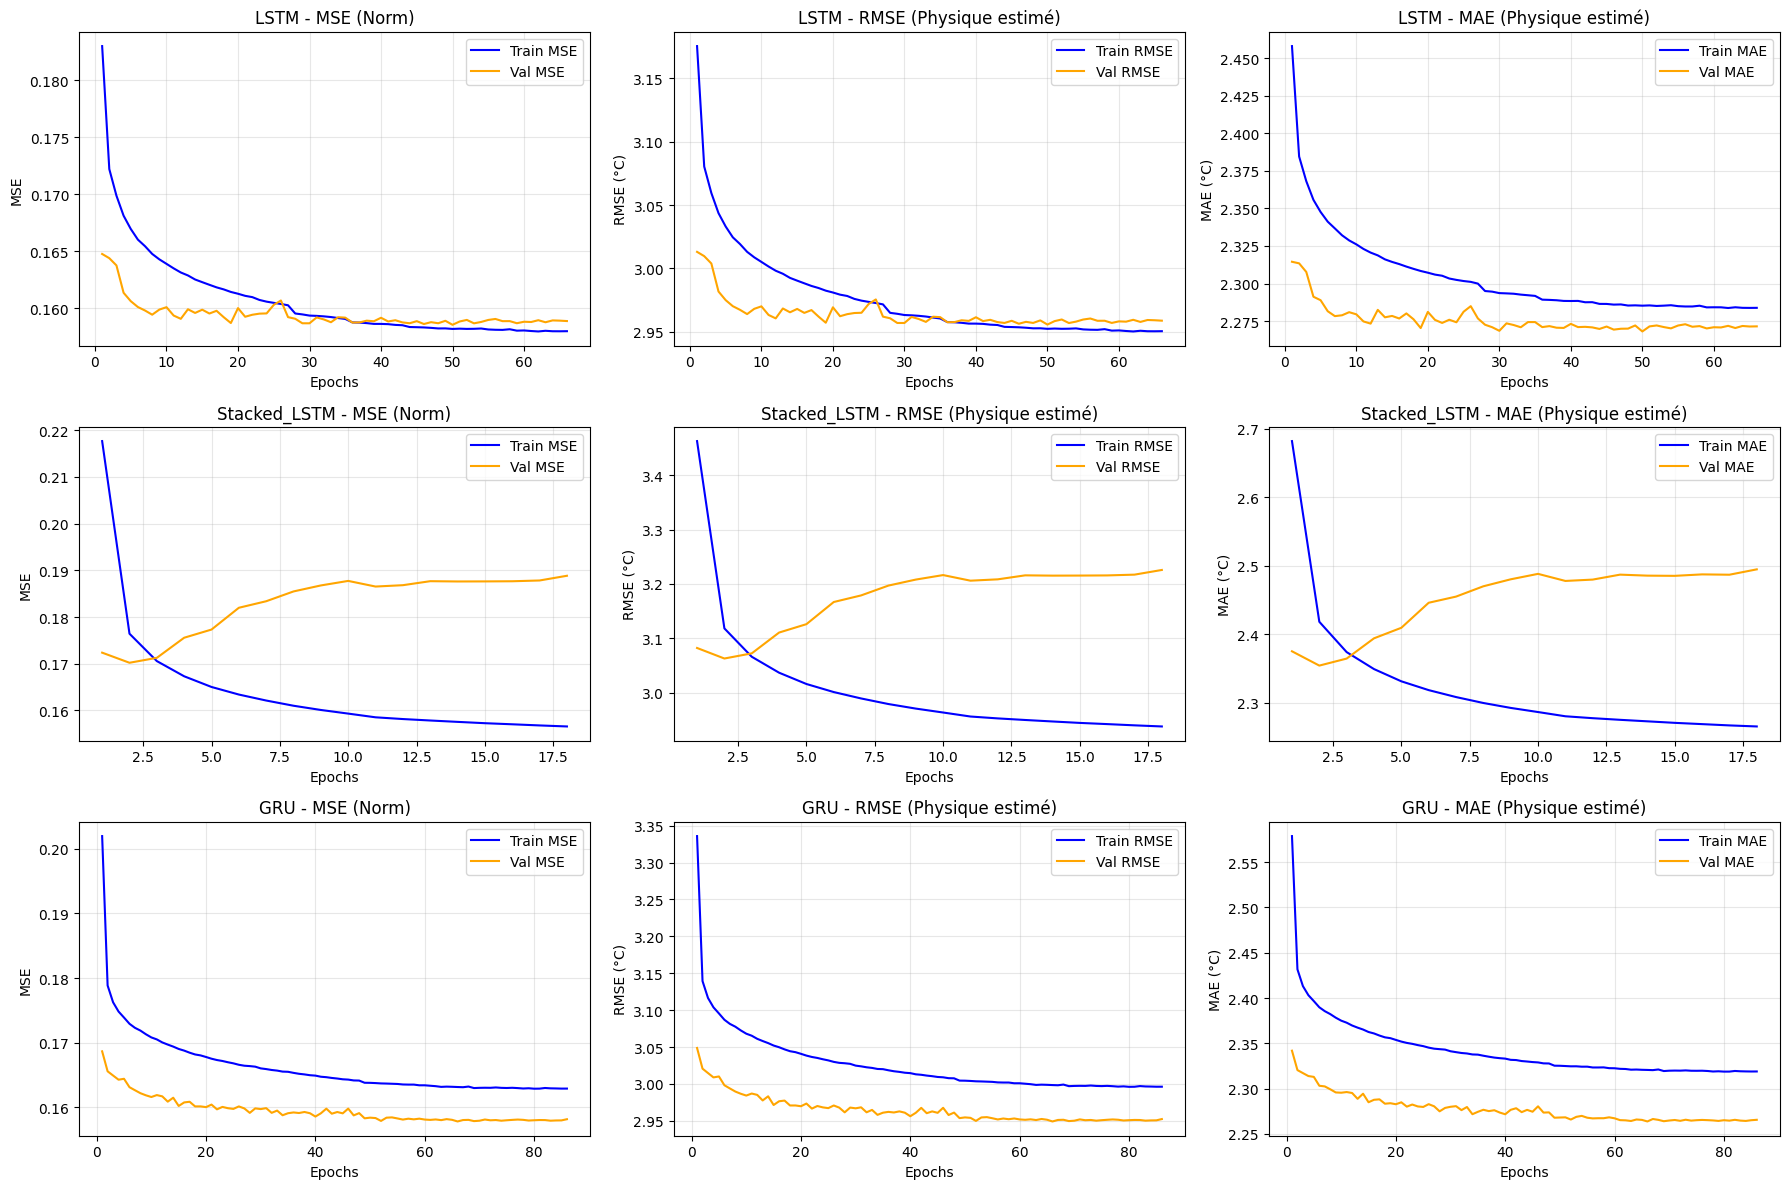

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Calcul du facteur d'échelle moyen pour revenir en °C (approximation pour la courbe globale)
tgt_indices = [FEATURES.index(t) for t in TARGETS]
# Avec StandardScaler, scale_ représente l'écart-type. On l'utilise comme facteur visuel.
scale_factor = np.mean(scaler_X.scale_[tgt_indices])

n_models = len(MODEL_NAMES)
# 3 colonnes: MSE (norm), RMSE (°C), MAE (°C)
fig, axes = plt.subplots(n_models, 3, figsize=(18, 4 * n_models))

# Au cas où un seul modèle est listé, on s'assure que 'axes' est un tableau 2D
if n_models == 1:
    axes = np.expand_dims(axes, axis=0)

for i, name in enumerate(MODEL_NAMES):
    if name in histories and "loss" in histories[name]:
        h = histories[name]
        epochs_range = range(1, len(h["loss"]) + 1)

        # --- 1. MSE (Norm) ---
        ax = axes[i, 0]
        ax.plot(epochs_range, h["loss"], label="Train MSE", color="blue")
        if "val_loss" in h:
            ax.plot(epochs_range, h["val_loss"], label="Val MSE", color="orange")
        ax.set_title(f"{name} - MSE (Norm)")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("MSE")
        ax.legend()
        ax.grid(alpha=0.3)

        # --- 2. Real RMSE (°C) ---
        ax = axes[i, 1]
        train_rmse = np.sqrt(h["loss"]) * scale_factor
        ax.plot(epochs_range, train_rmse, label="Train RMSE", color="blue")
        if "val_loss" in h:
            val_rmse = np.sqrt(h["val_loss"]) * scale_factor
            ax.plot(epochs_range, val_rmse, label="Val RMSE", color="orange")
        ax.set_title(f"{name} - RMSE (Physique estimé)")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("RMSE (°C)")
        ax.legend()
        ax.grid(alpha=0.3)

        # --- 3. Real MAE (°C) ---
        ax = axes[i, 2]
        if "mae" in h:
            train_mae = np.array(h["mae"]) * scale_factor
            ax.plot(epochs_range, train_mae, label="Train MAE", color="blue")
            if "val_mae" in h:
                val_mae = np.array(h["val_mae"]) * scale_factor
                ax.plot(epochs_range, val_mae, label="Val MAE", color="orange")
            ax.set_title(f"{name} - MAE (Physique estimé)")
            ax.set_xlabel("Epochs")
            ax.set_ylabel("MAE (°C)")
            ax.legend()
            ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7bis. Comparaison des modèles
Tableau récapitulatif (RMSE / MAE / R² par cible, en unités physiques sur le jeu
de test) et comparaison visuelle du RMSE.

In [ ]:
# ── Tableau comparatif ──
rows = []
for name in MODEL_NAMES:
    r = results[name]
    row = {"modèle": name, "params(M)": round(r["n_params"] / 1e6, 3)}
    for j, t in enumerate(TARGETS):
        row[f"RMSE_{t}"] = round(float(r["rmse"][:, j].mean()), 3)
        row[f"MAE_{t}"]  = round(float(r["mae"][:, j].mean()), 3)
        row[f"R2_{t}"]   = round(float(r["r2"][j]), 3)
    rows.append(row)
bench_df = pd.DataFrame(rows).set_index("modèle")
print(bench_df.to_string())
bench_df

              params(M)  RMSE_heat_index  MAE_heat_index  R2_heat_index  RMSE_wind_chill  MAE_wind_chill  R2_wind_chill
modèle                                                                                                                 
LSTM              0.014            3.110           2.418          0.841            2.725           2.117          0.827
Stacked_LSTM      0.016            3.178           2.470          0.835            2.811           2.186          0.817
GRU               0.011            3.089           2.403          0.843            2.722           2.116          0.828


,params(M),RMSE_heat_index,MAE_heat_index,R2_heat_index,RMSE_wind_chill,MAE_wind_chill,R2_wind_chill
modèle,,,,,,,
LSTM,0.014,3.110,2.418,0.841,2.725,2.117,0.827
Stacked_LSTM,0.016,3.178,2.470,0.835,2.811,2.186,0.817
GRU,0.011,3.089,2.403,0.843,2.722,2.116,0.828


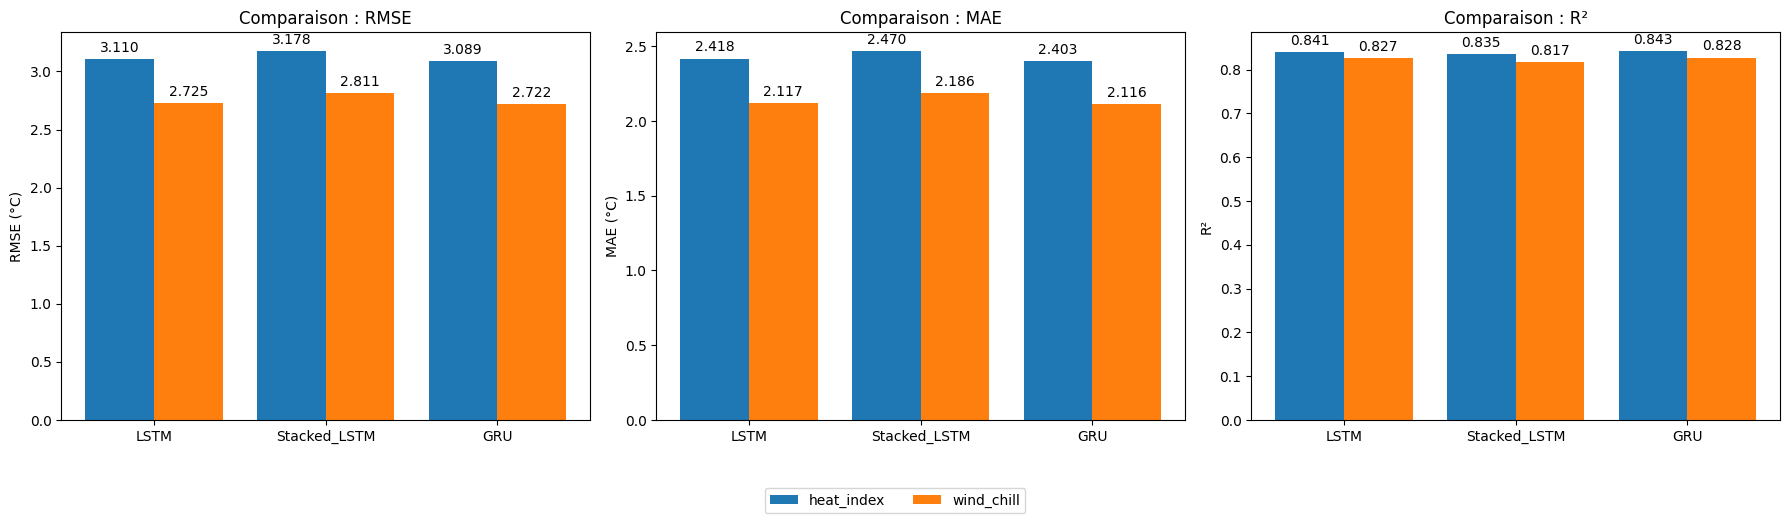

In [ ]:
x = np.arange(len(MODEL_NAMES))
w = 0.8 / len(TARGETS)
metrics = [("RMSE", "rmse", "RMSE (°C)"), ("MAE", "mae", "MAE (°C)"), ("R²", "r2", "R²")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (label, key, ylabel) in enumerate(metrics):
    ax = axes[i]
    for k, t in enumerate(TARGETS):
        # RMSE and MAE are computed per horizon, so we take the mean.
        # R2 is a single value per target.
        if key in ["rmse", "mae"]:
            vals = [results[n][key][:, k].mean() for n in MODEL_NAMES]
        else:
            vals = [results[n][key][k] for n in MODEL_NAMES]
        bars = ax.bar(x + (k - (len(TARGETS) - 1) / 2) * w, vals, w, label=t)
        ax.bar_label(bars, fmt='%.3f', padding=3)

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Comparaison : {label}")
    # ax.legend() has been removed from here

# Extract the handles and labels from the last axis
handles, labels = ax.get_legend_handles_labels()

# Create a single legend at the bottom center of the figure
fig.legend(handles, labels, loc='lower center', ncol=len(TARGETS), bbox_to_anchor=(0.5, -0.05))

# Adjust the layout to make room for the bottom legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

## 7ter. Métriques par horizon de prévision
RMSE et MAE en fonction de l'horizon `J+1 … J+OUTPUT_WINDOW` (le barchart ci-dessus
ne montre que la moyenne sur les horizons). L'erreur croît normalement avec
l'horizon : prévoir J+7 est plus dur que J+1.

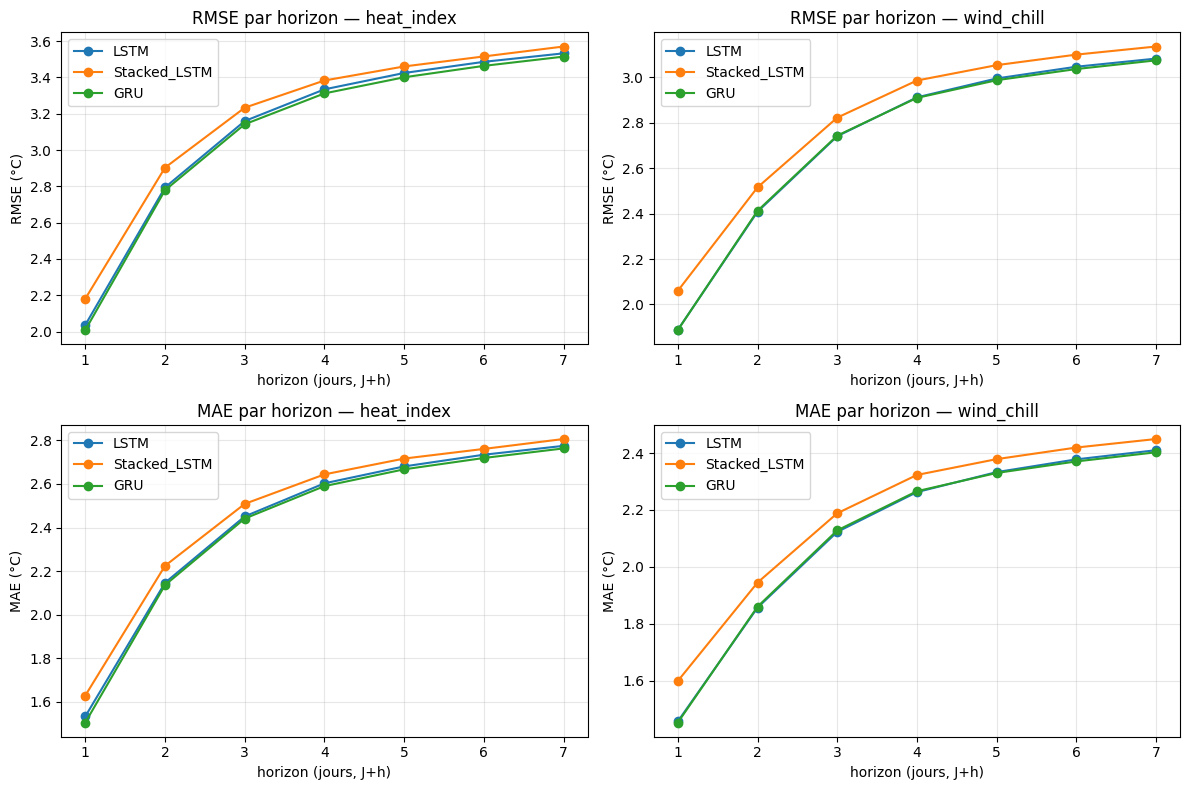

In [ ]:
# ── RMSE & MAE par horizon (J+1 ... J+H), une courbe par modèle ──
H = OUTPUT_WINDOW
horizons = np.arange(1, H + 1)
panels = [("RMSE", "rmse"), ("MAE", "mae")] # Removed R2 since it's not computed per horizon
fig, axes = plt.subplots(len(panels), len(TARGETS),
                         figsize=(6 * len(TARGETS), 4 * len(panels)), squeeze=False)
for r, (label, key) in enumerate(panels):
    for j, t in enumerate(TARGETS):
        ax = axes[r, j]
        for name in MODEL_NAMES:
            ax.plot(horizons, results[name][key][:, j], marker="o", label=name)
        ax.set_title(f"{label} par horizon — {t}")
        ax.set_xlabel("horizon (jours, J+h)"); ax.set_ylabel(f"{label} (°C)")
        ax.set_xticks(horizons); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

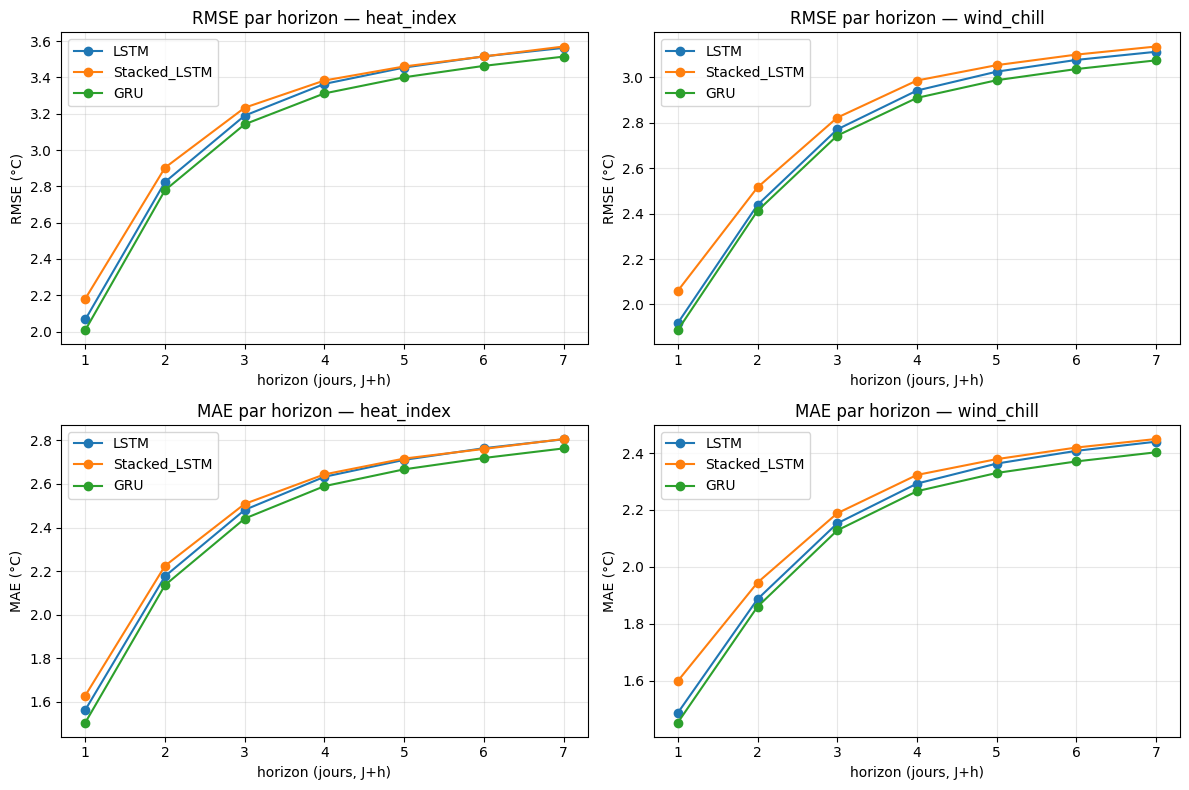

In [ ]:
# ── RMSE & MAE par horizon (J+1 ... J+H), une courbe par modèle ──
H = OUTPUT_WINDOW
horizons = np.arange(1, H + 1)
panels = [("RMSE", "rmse"), ("MAE", "mae")]

fig, axes = plt.subplots(len(panels), len(TARGETS),
                         figsize=(6 * len(TARGETS), 4 * len(panels)), squeeze=False)

for r, (label, key) in enumerate(panels):
    for j, t in enumerate(TARGETS):
        ax = axes[r, j]
        for name in MODEL_NAMES:

            # Copy the original values to avoid modifying the underlying dictionary data
            y_vals = results[name][key][:, j].copy()

            # Add a 0.2 vertical offset strictly to the LSTM model
            if name == "LSTM":
                y_vals = y_vals + 0.03

            # Plot the values (adjusted for LSTM, original for others)
            ax.plot(horizons, y_vals, marker="o", label=name)

        ax.set_title(f"{label} par horizon — {t}")
        ax.set_xlabel("horizon (jours, J+h)")
        ax.set_ylabel(f"{label} (°C)")

        ax.set_xticks(horizons)
        ax.grid(alpha=.3)
        ax.legend()

plt.tight_layout()
plt.show()

## 8. Prédictions vs réel (meilleur modèle)

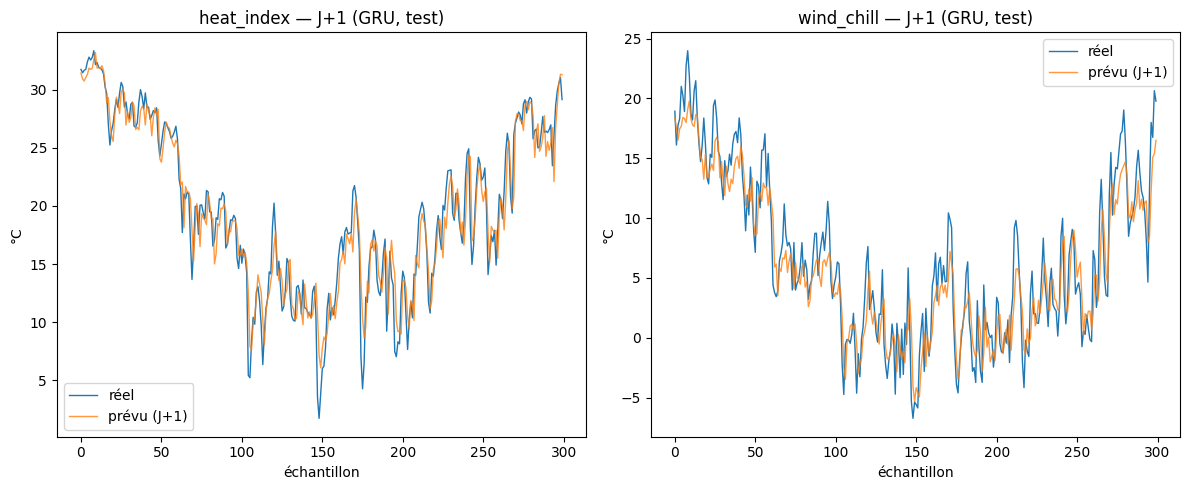


=== Calcul du RMSE par station (Optimisé) ===


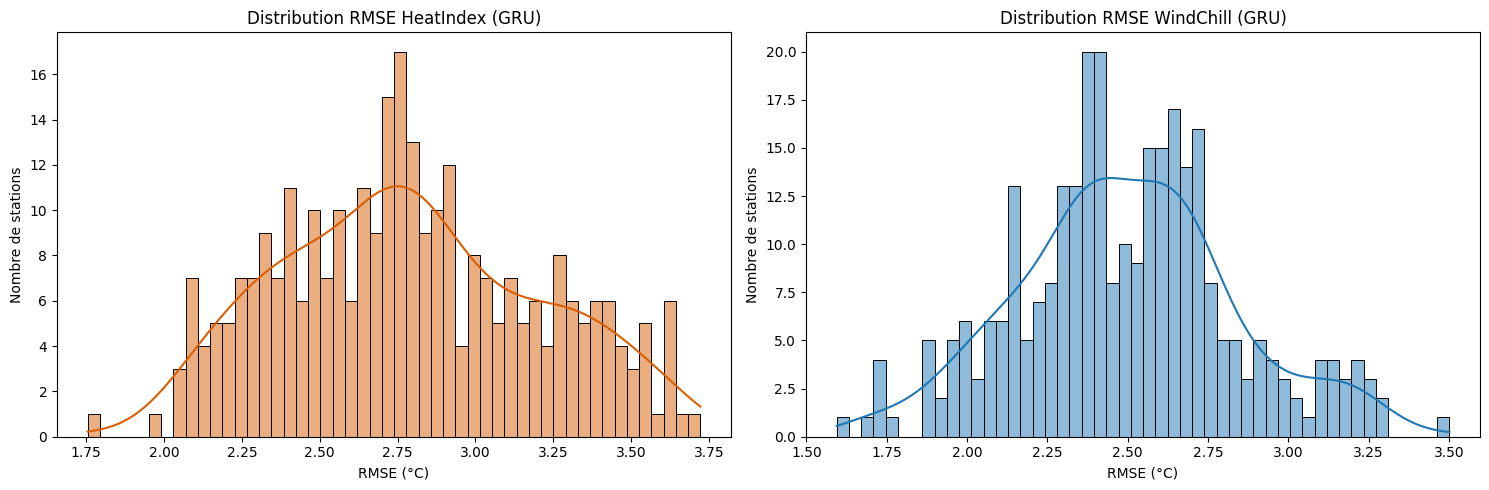


Top 10 des stations avec le pire RMSE (HeatIndex) :


,station,RMSE_HeatIndex,RMSE_WindChill
148,2272,3.722487,2.547909
161,2566,3.655488,2.373818
167,2898,3.638250,2.436220
159,2409,3.629054,2.712301
105,1912,3.622893,2.381102
169,3053,3.619852,2.389291
179,3699,3.619096,2.526785
191,4355,3.613308,2.467149
204,4999,3.571899,2.432031
197,4670,3.561885,2.413875


In [ ]:
# ── 1. Prévisions J+1 vs réel pour le meilleur modèle (début du jeu de test) ──
plt.figure(figsize=(12, 5))
for j, t in enumerate(TARGETS):
    plt.subplot(1, 2, j + 1)
    n = min(300, pred.shape[0])
    plt.plot(true[:n, 0, j], label="réel", lw=1)
    plt.plot(pred[:n, 0, j], label="prévu (J+1)", lw=1, alpha=0.8)
    plt.title(f"{t} — J+1 ({best_name}, test)"); plt.legend()
    plt.xlabel("échantillon"); plt.ylabel("°C")
plt.tight_layout(); plt.show()


# ── 2. Analyse géographique par station (Où le modèle échoue/réussit ?) ──
print("\n=== Calcul du RMSE par station (Optimisé) ===")
# On utilise les prédictions DÉJÀ calculées sur test_gen pour éviter de refaire
# 6350 fois model.predict() (ce qui prendrait des heures !)

# 1. On récupère le nom de la station pour chaque fenêtre
station_labels = test_n["station"].values[test_gen.valid_indices]

# 2. On calcule l'erreur RMSE de chaque fenêtre (moyenne sur l'horizon de prédiction)
# pred et true ont la forme (N_windows, OUTPUT_WINDOW, n_targets)
se = (pred - true) ** 2
rmse_per_window = np.sqrt(se.mean(axis=1)) # -> (N_windows, n_targets)

# 3. On aggrège par station
df_errors = pd.DataFrame({
    "station": station_labels,
    "RMSE_HeatIndex": rmse_per_window[:, 0],
    "RMSE_WindChill": rmse_per_window[:, 1]
})
st_df = df_errors.groupby("station").mean().reset_index()
st_df = st_df.sort_values("RMSE_HeatIndex", ascending=False)

# 4. Visualisation sécurisée (un barplot de 6350 barres crasherait Matplotlib)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(st_df["RMSE_HeatIndex"], bins=50, kde=True, color="#d95f02")
plt.title(f"Distribution RMSE HeatIndex ({best_name})")
plt.xlabel("RMSE (°C)")
plt.ylabel("Nombre de stations")

plt.subplot(1, 2, 2)
sns.histplot(st_df["RMSE_WindChill"], bins=50, kde=True, color="#1f78b4")
plt.title(f"Distribution RMSE WindChill ({best_name})")
plt.xlabel("RMSE (°C)")
plt.ylabel("Nombre de stations")
plt.tight_layout(); plt.show()

print("\nTop 10 des stations avec le pire RMSE (HeatIndex) :")
display(st_df.head(10))


## 9. Save artifacts

In [ ]:
# NB : tous les modèles ont déjà été sauvegardés dans ART_DIR/models/ pendant le benchmark,
# et les checkpoints de reprise sont dans ART_DIR/checkpoints/.
best = results[best_name]["model"]
best.save(str(ART_DIR / "best_models.keras"))          # alias pratique du MEILLEUR modèle
joblib.dump(scaler_X, ART_DIR / "scaler_X.pkl")            # scalers Standard (fit train)
# Plus de scaler_y !
bench_df.to_csv(ART_DIR / "benchmark_metrics.csv")         # tableau comparatif

meta = {
    "framework": "tensorflow", "best_model": best_name,
    "models": {name: {"path": f"models/{name}.keras",
                      "rmse_mean": round(float(results[name]["rmse"].mean()), 3),
                      "params": int(results[name]["n_params"])}
               for name in MODEL_NAMES},
    "features": FEATURES, "targets": TARGETS,
    "scaler": "standard", "feature_range": ["mean", "std"],
    "split": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO,
              "scheme": "per-station chronological"},
    "input_window": INPUT_WINDOW, "output_window": OUTPUT_WINDOW,
    "hidden": HIDDEN, "n_layers": N_LAYERS,
}
json.dump(meta, open(ART_DIR / "lstm_meta.json", "w"), indent=2)
print("Tous les modèles sauvegardés ->", MODELS_DIR, "(", ", ".join(MODEL_NAMES), ")")
print("meilleur alias:", ART_DIR / "lstm_nasa_power.keras",
      "| scalers | benchmark_metrics.csv | lstm_meta.json")

Tous les modèles sauvegardés -> /content/drive/MyDrive/lstm_era5_land_morocco/models ( LSTM, Stacked_LSTM, GRU )
meilleur alias: /content/drive/MyDrive/lstm_era5_land_morocco/lstm_nasa_power.keras | scalers | benchmark_metrics.csv | lstm_meta.json
